In [2]:
import polars as pl
import matplotlib.pyplot as plt

In [3]:

sequence_cols = [f"BindingDB Target Chain Sequence {i}" for i in range(1, 51)]

lazy_df = pl.scan_csv("BindingDB_All.tsv", separator="\t", ignore_errors=True, quote_char=None)

df_validated = (
    lazy_df
    .with_columns([
        # 1. Przygotowanie n_chains
        pl.col("Number of Protein Chains in Target (>1 implies a multichain complex)")
          .cast(pl.Int32, strict=False)
          .fill_null(1)
          .alias("n_chains"),
          
        # 2. Liczymy, ile kolumn sekwencji faktycznie NIE jest nullem
        pl.sum_horizontal([pl.col(c).is_not_null().cast(pl.Int32) for c in sequence_cols])
          .alias("actual_seq_count")
    ])
    .with_columns([
        # 3. Sprawdzamy spójność
        (pl.col("n_chains") == pl.col("actual_seq_count")).alias("is_consistent"),
        
        # 4. Łączymy sekwencje (tak jak wcześniej)
        pl.concat_str(
            [pl.col(c).fill_null("") for c in sequence_cols],
            separator=":"
        ).str.strip_chars(":").alias("Full_Protein_Sequence")
    ])
    .with_columns([
        pl.col("Ki (nM)")
          # 1. Usuwamy wszystko poza cyframi i kropką (regex: [^0-9.])
          .str.replace_all(r"[^0-9.]", "")
          # 2. Jeśli po czyszczeniu został pusty ciąg, zamień na null
          .replace("", None)
          # 3. Teraz cast na liczbę zadziała znacznie częściej
          .cast(pl.Float64, strict=False)
    ])
    # 5. Ostateczne czyszczenie
    .filter(
        (pl.col("Ligand SMILES").is_not_null()) & 
        (pl.col("Full_Protein_Sequence") != "") &
        (pl.col("is_consistent") == True) # Opcjonalnie: wyrzucamy niespójne dane
    )
    .select([
        "Ligand SMILES",
        "Full_Protein_Sequence",
        "Ki (nM)",
    ])
    .collect()
)

print(df_validated.head())

shape: (5, 3)
┌─────────────────────────────────┬─────────────────────────────────┬─────────┐
│ Ligand SMILES                   ┆ Full_Protein_Sequence           ┆ Ki (nM) │
│ ---                             ┆ ---                             ┆ ---     │
│ str                             ┆ str                             ┆ f64     │
╞═════════════════════════════════╪═════════════════════════════════╪═════════╡
│ O[C@@H]1[C@@H](O)[C@@H](Cc2ccc… ┆ PQITLWQRPLVTIKIGGQLKEALLDTGADD… ┆ 0.24    │
│ O[C@@H]1[C@@H](O)[C@@H](Cc2ccc… ┆ PQITLWQRPLVTIKIGGQLKEALLDTGADD… ┆ 0.25    │
│ O[C@@H]1[C@@H](O)[C@@H](Cc2ccc… ┆ PQITLWQRPLVTIKIGGQLKEALLDTGADD… ┆ 0.41    │
│ OCCCCCCN1[C@H](Cc2ccccc2)[C@H]… ┆ PQITLWQRPLVTIKIGGQLKEALLDTGADD… ┆ 0.8     │
│ OCCCCCN1[C@H](Cc2ccccc2)[C@H](… ┆ PQITLWQRPLVTIKIGGQLKEALLDTGADD… ┆ 0.99    │
└─────────────────────────────────┴─────────────────────────────────┴─────────┘


In [4]:
df_validated.shape

(3048203, 3)

In [5]:
print(df_validated.null_count())

shape: (1, 3)
┌───────────────┬───────────────────────┬─────────┐
│ Ligand SMILES ┆ Full_Protein_Sequence ┆ Ki (nM) │
│ ---           ┆ ---                   ┆ ---     │
│ u32           ┆ u32                   ┆ u32     │
╞═══════════════╪═══════════════════════╪═════════╡
│ 0             ┆ 0                     ┆ 2445260 │
└───────────────┴───────────────────────┴─────────┘


In [6]:
df_clean = df_validated.drop_nulls()
df_clean.shape
df_clean.head()

Ligand SMILES,Full_Protein_Sequence,Ki (nM)
str,str,f64
"""O[C@@H]1[C@@H](O)[C@@H](Cc2ccc…","""PQITLWQRPLVTIKIGGQLKEALLDTGADD…",0.24
"""O[C@@H]1[C@@H](O)[C@@H](Cc2ccc…","""PQITLWQRPLVTIKIGGQLKEALLDTGADD…",0.25
"""O[C@@H]1[C@@H](O)[C@@H](Cc2ccc…","""PQITLWQRPLVTIKIGGQLKEALLDTGADD…",0.41
"""OCCCCCCN1[C@H](Cc2ccccc2)[C@H]…","""PQITLWQRPLVTIKIGGQLKEALLDTGADD…",0.8
"""OCCCCCN1[C@H](Cc2ccccc2)[C@H](…","""PQITLWQRPLVTIKIGGQLKEALLDTGADD…",0.99


In [7]:
smiles_hist = df_clean["Ligand SMILES"].value_counts(sort=True)
count_distribution = (
    smiles_hist["count"]
    .alias("c")
    .value_counts()
    .sort("count") # Sortujemy po liczbie wystąpień (1, 2, 3...)
)
count_distribution

c,count
u32,u32
1863,1
990,1
461,1
408,1
400,1
…,…
5,6203
4,19583
3,28106


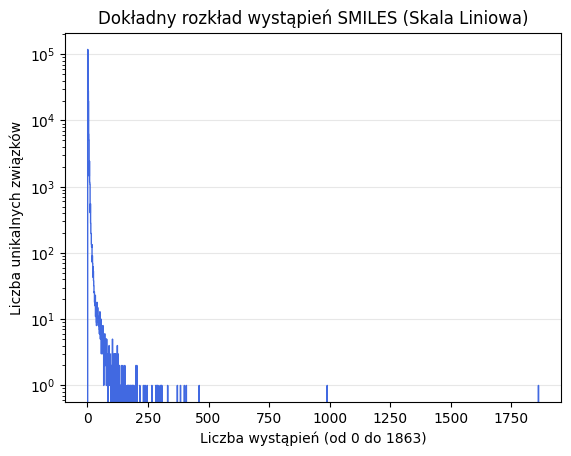

In [8]:
plt.hist(
    smiles_hist["count"], 
    bins=1863, 
    log=True,
    color='royalblue',
    histtype='step' # 'step' jest szybszy przy tysiącach słupków i wygląda czyściej
)

plt.title("Dokładny rozkład wystąpień SMILES (Skala Liniowa)")
plt.xlabel("Liczba wystąpień (od 0 do 1863)")
plt.ylabel("Liczba unikalnych związków")

# Opcjonalnie: ograniczenie osi X, jeśli chcesz zobaczyć "początek" wykresu
# plt.xlim(0, 100) 

plt.grid(axis='y', alpha=0.3)
plt.show()

In [9]:
pl.Config.set_fmt_str_lengths(1000)
print(tuple(df_clean["Full_Protein_Sequence"].value_counts(sort=True)[:10]))

(shape: (10,)
Series: 'Full_Protein_Sequence' [str]
[
	"MDPLNLSWYDDDLERQNWSRPFNGSDGKADRPHYNYYATLLTLLIAVIVFGNVLVCMAVSREKALQTTTNYLIVSLAVADLLVATLVMPWVVYLEVVGEWKFSRIHCDIFVTLDVMMCTASILNLCAISIDRYTAVAMPMLYNTRYSSKRRVTVMISIVWVLSFTISCPLLFGLNNADQNECIIANPAFVVYSSIVSFYVPFIVTLLVYIKIYIVLRRRRKRVNTKRSSRAFRAHLRAPLKGNCTHPEDMKLCTVIMKSNGSFPVNRRRVEAARRAQELEMEMLSSTSPPERTRYSPIPPSHHQLTLPDPSHHGLHSTPDSPAKPEKNGHAKDHPKIAKIFEIQTMPNGKTRTSLKTMSRRKLSQQKEKKATQMLAIVLGVFIICWLPFFITHILNIHCDCNIPPVLYSAFTWLGYVNSAVNPIIYTTFNIEFRKAFLKILHC"
	"MSHHWGYGKHNGPEHWHKDFPIAKGERQSPVDIDTHTAKYDPSLKPLSVSYDQATSLRILNNGHAFNVEFDDSQDKAVLKGGPLDGTYRLIQFHFHWGSLDGQGSEHTVDKKKYAAELHLVHWNTKYGDFGKAVQQPDGLAVLGIFLKVGSAKPGLQKVVDVLDSIKTKGKSADFTNFDPRGLLPESLDYWTYPGSLTTPPLLECVTWIVLKEPISVSSEQVLKFRKLNFNGEGEPEELMVDNWRPAQPLKNRQIKASFK"
	"MASPDWGYDDKNGPEQWSKLYPIANGNNQSPVDIKTSETKHDTSLKPISVSYNPATAKEIINVGHSFHVNFEDNDNRSVLKGGPFSDSYRLFQFHFHWGSTNEHGSEHTVDGVKYSAELHVAHWNSAKYSSLAEAASKADGLAVIGVLMKVGEANPKLQKVLDALQAIKTKGKRAPFTNFDPSTLLPSSLDFWTYPGSLTHPPLYESVTWIICKESISVSSEQLAQFRSLLSN

In [10]:
df_clean_dedup = (
    df_clean
    .group_by(["Ligand SMILES", "Full_Protein_Sequence"])
    .agg(
        pl.col("Ki (nM)").mean().alias("Ki (nM)")
    )
)

print("Before:", df_clean.shape)
print("After dedup:", df_clean_dedup.shape)

Before: (602943, 3)
After dedup: (482651, 3)


In [11]:
from tdc.multi_pred import DTI

# Pobieranie i ładowanie BindingDB z konkretnym filtrem (np. tylko Ki)
data = DTI(name = 'BindingDB_Ki')

# Wyświetlenie tabeli (automatycznie dostaniesz SMILES, Sequence i Label)
d = data.get_data()
print(d.head())

Found local copy...
Loading...
Done!


     Drug_ID                                               Drug Target_ID  \
0  3081361.0      COc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCC1CCN(C)CC1       NaN   
1  5327236.0  O=C1N(C/C=C/c2cn[nH]c2)[C@H](Cc2ccccc2)[C@H](O...       NaN   
2  5327235.0  O=C1N(C/C=C/c2cn[nH]c2)[C@H](Cc2ccccc2)[C@H](O...       NaN   
3  5327234.0  O=C1N(CCCCCCO)[C@H](Cc2ccccc2)[C@H](O)[C@@H](O...       NaN   
4  3009319.0  O=C1N(CCCCCO)[C@H](Cc2ccccc2)[C@H](O)[C@@H](O)...       NaN   

                                              Target     Y  
0  PQITLWQRPLVTIKIGGQLKEALLDTGADDTVLEEMSLPGRWKPKM...  0.24  
1  PQITLWQRPLVTIKIGGQLKEALLDTGADDTVLEEMSLPGRWKPKM...  0.25  
2  PQITLWQRPLVTIKIGGQLKEALLDTGADDTVLEEMSLPGRWKPKM...  0.41  
3  PQITLWQRPLVTIKIGGQLKEALLDTGADDTVLEEMSLPGRWKPKM...  0.80  
4  PQITLWQRPLVTIKIGGQLKEALLDTGADDTVLEEMSLPGRWKPKM...  0.99  


In [12]:
d.shape

(374820, 5)

In [13]:
# === PORÓWNANIE DATASETÓW ===
print("=" * 60)
print("PORÓWNANIE: Twój dataset (df_clean_dedup) vs TDC (d)")
print("=" * 60)

print("\n1. WYMIARY:")
print(f"Twój dataset (df_clean_dedup): {df_clean_dedup.shape}")
print(f"TDC dataset (d):              {d.shape}")
print(f"Różnica w wierszach: {d.shape[0] - df_clean_dedup.shape[0]}")

print("\n2. NAZWY KOLUMN:")
print(f"Twoje kolumny:     {df_clean_dedup.columns}")
print(f"TDC kolumny:       {d.columns}")

print("\n3. TYPY DANYCH:")
print("Twój dataset:")
print(df_clean_dedup.schema)
print("\nTDC dataset:")
if isinstance(d, pl.DataFrame):
    print(d.schema)
else:
    print(f"Typy: {dict(d.dtypes)}")

PORÓWNANIE: Twój dataset (df_clean_dedup) vs TDC (d)

1. WYMIARY:
Twój dataset (df_clean_dedup): (482651, 3)
TDC dataset (d):              (374820, 5)
Różnica w wierszach: -107831

2. NAZWY KOLUMN:
Twoje kolumny:     ['Ligand SMILES', 'Full_Protein_Sequence', 'Ki (nM)']
TDC kolumny:       Index(['Drug_ID', 'Drug', 'Target_ID', 'Target', 'Y'], dtype='object')

3. TYPY DANYCH:
Twój dataset:
Schema([('Ligand SMILES', String), ('Full_Protein_Sequence', String), ('Ki (nM)', Float64)])

TDC dataset:
Typy: {'Drug_ID': dtype('float64'), 'Drug': dtype('O'), 'Target_ID': dtype('O'), 'Target': dtype('O'), 'Y': dtype('float64')}


In [14]:

# Przygotowanie danych TDC do porównania
# TDC używa standardowych kolumn dla DTI: Y_pred (label) zamiast Ki
print("\n4. STATYSTYKI Ki (nM):")
print("Twój dataset:")
print(df_clean_dedup["Ki (nM)"].describe())
print(f"Null count: {df_clean_dedup['Ki (nM)'].null_count()}")

print("\nTDC dataset (Y - label):")
print(d["Y"].describe())
if isinstance(d, pl.DataFrame):
    print(f"Null count: {d['Y'].null_count()}")
else:
    print(f"Null count: {d['Y'].isna().sum()}")

print("\n5. PORÓWNANIE ROZKŁADÓW:")
print(f"Twoja min Ki: {df_clean_dedup['Ki (nM)'].min()}, max: {df_clean_dedup['Ki (nM)'].max()}")
print(f"TDC min Y:    {d['Y'].min()}, max: {d['Y'].max()}")

# Konwersja TDC dataframe do Polars jeśli potrzeba
if not isinstance(d, pl.DataFrame):
    print("\nKonwertowanie TDC na Polars...")
    d_pl = pl.from_pandas(d) if hasattr(d, 'to_pandas') else pl.DataFrame(d)
else:
    d_pl = d

print(d_pl.head())



4. STATYSTYKI Ki (nM):
Twój dataset:
shape: (9, 2)
┌────────────┬───────────────┐
│ statistic  ┆ value         │
│ ---        ┆ ---           │
│ str        ┆ f64           │
╞════════════╪═══════════════╡
│ count      ┆ 482651.0      │
│ null_count ┆ 0.0           │
│ mean       ┆ 249217.799846 │
│ std        ┆ 1.0396e7      │
│ min        ┆ 0.0           │
│ 25%        ┆ 9.7           │
│ 50%        ┆ 119.0         │
│ 75%        ┆ 1799.0        │
│ max        ┆ 4.0000e9      │
└────────────┴───────────────┘
Null count: 0

TDC dataset (Y - label):
count    3.748200e+05
mean     3.371311e+04
std      3.545086e+05
min      0.000000e+00
25%      9.800000e+00
50%      1.230000e+02
75%      1.940000e+03
max      1.000000e+07
Name: Y, dtype: float64
Null count: 0

5. PORÓWNANIE ROZKŁADÓW:
Twoja min Ki: 0.0, max: 4000000000.0
TDC min Y:    0.0, max: 10000000.0

Konwertowanie TDC na Polars...
shape: (5, 5)
┌────────────┬─────────────────────────────────┬───────────┬─────────────────────────

In [15]:
# 6. ANALIZA POKRYWANIA SIĘ DANYCH
print("\n6. POKRYWANIE SIĘ DATASETÓW (OVERLAP):")

# Konwersja do Polars jeśli potrzeba
if not isinstance(d_pl, pl.DataFrame):
    d_pl = pl.from_pandas(d_pl) if hasattr(d_pl, "to_pandas") else pl.DataFrame(d_pl)

# Znormalizuj nazwy kolumn TDC
possible_drug_cols = ["X_drug", "Drug", "SMILES", "Ligand SMILES"]
possible_target_cols = ["X_target", "Target", "Sequence", "Full_Protein_Sequence", "Protein_Sequence"]
possible_label_cols = ["Y", "Label", "Ki (nM)", "Y_pred"]

drug_col = next((col for col in possible_drug_cols if col in d_pl.columns), None)
target_col = next((col for col in possible_target_cols if col in d_pl.columns), None)
label_col = next((col for col in possible_label_cols if col in d_pl.columns), None)

print(f"Znalezione kolumny: drug={drug_col}, target={target_col}, label={label_col}")

if not drug_col or not target_col:
    raise ValueError(f"Brak wymaganych kolumn dla porównania. Dostępne kolumny TDC: {d_pl.columns}")

# Tworzymy ramkę porównawczą przez aliasy (pewniejsze niż rename przy różnych wariantach kolumn)
d_compare = d_pl.select([
    pl.col(drug_col).alias("Ligand SMILES"),
    pl.col(target_col).alias("Full_Protein_Sequence"),
    pl.col(label_col).alias("Ki (nM)") if label_col else pl.lit(None).alias("Ki (nM)")
])

print(f"Kolumny po normalizacji: {d_compare.columns}")

# Połączyć dataframy do porównania
comparison = (
    df_clean_dedup
    .select(["Ligand SMILES", "Full_Protein_Sequence"])
    .join(
        d_compare.select(["Ligand SMILES", "Full_Protein_Sequence"]),
        on=["Ligand SMILES", "Full_Protein_Sequence"],
        how="inner"
    )
)

overlapping_pairs = comparison.unique().shape[0]

your_unique = df_clean_dedup.select(["Ligand SMILES", "Full_Protein_Sequence"]).unique()
tdc_unique = d_compare.select(["Ligand SMILES", "Full_Protein_Sequence"]).unique()

print(f"Wspólnych par SMILES-Sequence: {overlapping_pairs}")
print(f"Unikalnych SMILES-Sequence w Twoim datasecie: {your_unique.shape[0]}")
print(f"Unikalnych SMILES-Sequence w TDC: {tdc_unique.shape[0]}")

# Unikalne tylko w Twoim datasecie
only_yours = (
    your_unique
    .join(
        tdc_unique,
        on=["Ligand SMILES", "Full_Protein_Sequence"],
        how="anti"
    )
    .shape[0]
)

# Unikalne tylko w TDC
only_tdc = (
    tdc_unique
    .join(
        your_unique,
        on=["Ligand SMILES", "Full_Protein_Sequence"],
        how="anti"
    )
    .shape[0]
)

print(f"Unikalne tylko w Twoim datasecie: {only_yours}")
print(f"Unikalne tylko w TDC: {only_tdc}")


6. POKRYWANIE SIĘ DATASETÓW (OVERLAP):
Znalezione kolumny: drug=Drug, target=Target, label=Y
Kolumny po normalizacji: ['Ligand SMILES', 'Full_Protein_Sequence', 'Ki (nM)']
Wspólnych par SMILES-Sequence: 34984
Unikalnych SMILES-Sequence w Twoim datasecie: 482651
Unikalnych SMILES-Sequence w TDC: 334768
Unikalne tylko w Twoim datasecie: 447667
Unikalne tylko w TDC: 299784


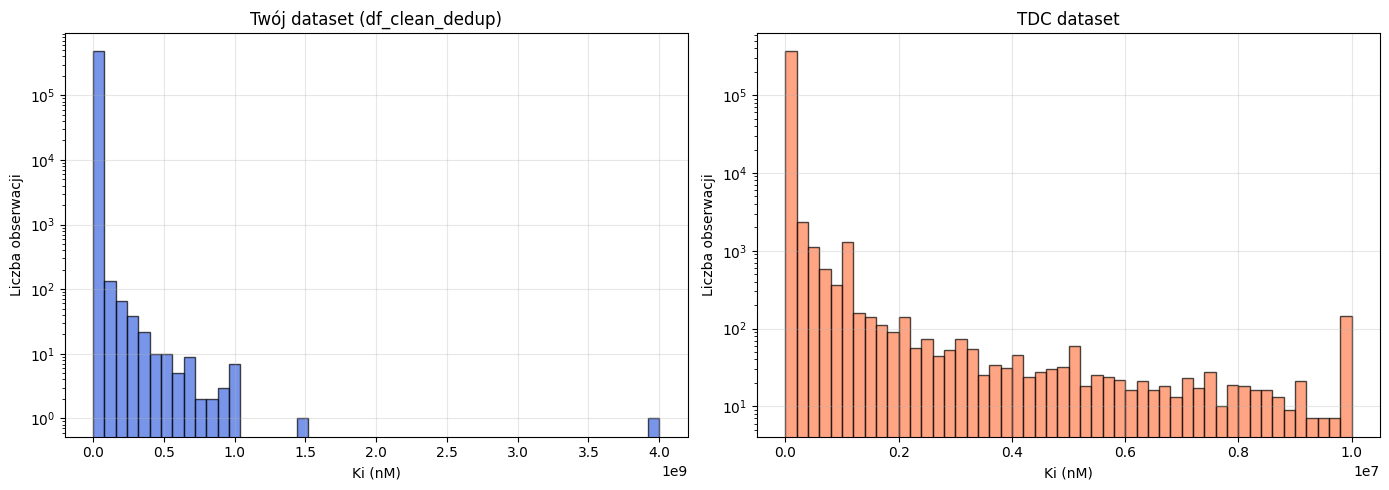


Statystyki porównawcze:
Twój dataset  - Srednia: 249217.80, Mediana: 119.00
TDC dataset   - Srednia: 33713.11, Mediana: 123.00


In [16]:
# 7. WIZUALIZACJA PORÓWNANIA ROZKŁADÓW
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Twój dataset
your_ki = df_clean_dedup["Ki (nM)"].to_numpy()
axes[0].hist(your_ki, bins=50, color="royalblue", alpha=0.7, edgecolor="black")
axes[0].set_xlabel("Ki (nM)")
axes[0].set_ylabel("Liczba obserwacji")
axes[0].set_title("Twój dataset (df_clean_dedup)")
axes[0].set_yscale("log")
axes[0].grid(alpha=0.3)

# TDC dataset
if "Ki (nM)" not in d_compare.columns:
    raise ValueError("Brak kolumny 'Ki (nM)' w znormalizowanym TDC. Uruchom najpierw komórkę 16.")

tdc_y = d_compare["Ki (nM)"].drop_nulls().to_numpy()
axes[1].hist(tdc_y, bins=50, color="coral", alpha=0.7, edgecolor="black")
axes[1].set_xlabel("Ki (nM)")
axes[1].set_ylabel("Liczba obserwacji")
axes[1].set_title("TDC dataset")
axes[1].set_yscale("log")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nStatystyki porównawcze:")
print(f"Twój dataset  - Srednia: {your_ki.mean():.2f}, Mediana: {pl.Series(your_ki).median():.2f}")
if len(tdc_y) > 0:
    print(f"TDC dataset   - Srednia: {tdc_y.mean():.2f}, Mediana: {pl.Series(tdc_y).median():.2f}")
else:
    print("TDC dataset   - brak niepustych wartości Ki do policzenia statystyk")

In [17]:
# 8. DIAGNOSTYKA RÓŻNIC: FORMAT VS RZECZYWISTE ROZBIEŻNOŚCI
# Zakłada, że komórka 16 została uruchomiona i istnieją: d_compare, your_unique, tdc_unique

if "your_unique" not in globals() or "tdc_unique" not in globals():
    raise ValueError("Uruchom najpierw komórkę 16 (overlap), aby utworzyć your_unique i tdc_unique.")

print("\n8. DIAGNOSTYKA RÓŻNIC")
print("=" * 60)

# 1) Jaki odsetek Twoich targetów to multi-chain (z ':')
your_multi_chain = (
    df_clean_dedup
    .with_columns(pl.col("Full_Protein_Sequence").str.contains(":").alias("is_multi"))
)
multi_count = your_multi_chain.filter(pl.col("is_multi") == True).height
total_count = your_multi_chain.height
multi_pct = (multi_count / total_count * 100) if total_count else 0.0

print("1) Multi-chain w Twoim zbiorze:")
print(f"   Rekordy multi-chain: {multi_count} / {total_count} ({multi_pct:.2f}%)")

# 2) Overlap po sprowadzeniu targetu do pierwszego łańcucha
your_first_chain = (
    your_unique
    .with_columns(
        pl.col("Full_Protein_Sequence")
        .str.split(":")
        .list.first()
        .alias("Target_first_chain")
    )
    .select(["Ligand SMILES", "Target_first_chain"])
    .unique()
)

tdc_first_chain = (
    tdc_unique
    .with_columns(
        pl.col("Full_Protein_Sequence")
        .str.split(":")
        .list.first()
        .alias("Target_first_chain")
    )
    .select(["Ligand SMILES", "Target_first_chain"])
    .unique()
)

overlap_first_chain = (
    your_first_chain.join(
        tdc_first_chain,
        on=["Ligand SMILES", "Target_first_chain"],
        how="inner"
    )
    .unique()
    .height
)

print("\n2) Overlap po redukcji targetu do pierwszego łańcucha:")
print(f"   Wspólnych par: {overlap_first_chain}")

# 3) Overlap po lekkiej normalizacji SMILES (trim + upper)
def normalize_smiles_expr(col_name: str) -> pl.Expr:
    return (
        pl.col(col_name)
        .cast(pl.Utf8)
        .str.strip_chars()
        .str.to_uppercase()
    )

your_norm = (
    your_unique
    .with_columns([
        normalize_smiles_expr("Ligand SMILES").alias("SMILES_norm"),
        pl.col("Full_Protein_Sequence").alias("Target_norm")
    ])
    .select(["SMILES_norm", "Target_norm"])
    .unique()
)

tdc_norm = (
    tdc_unique
    .with_columns([
        normalize_smiles_expr("Ligand SMILES").alias("SMILES_norm"),
        pl.col("Full_Protein_Sequence").alias("Target_norm")
    ])
    .select(["SMILES_norm", "Target_norm"])
    .unique()
)

overlap_norm_smiles = (
    your_norm.join(
        tdc_norm,
        on=["SMILES_norm", "Target_norm"],
        how="inner"
    )
    .unique()
    .height
)

print("\n3) Overlap po lekkiej normalizacji SMILES (trim + uppercase):")
print(f"   Wspólnych par: {overlap_norm_smiles}")

# 4) Overlap po obu zabiegach jednocześnie
your_both = (
    your_unique
    .with_columns([
        normalize_smiles_expr("Ligand SMILES").alias("SMILES_norm"),
        pl.col("Full_Protein_Sequence").str.split(":").list.first().alias("Target_first_chain")
    ])
    .select(["SMILES_norm", "Target_first_chain"])
    .unique()
)

tdc_both = (
    tdc_unique
    .with_columns([
        normalize_smiles_expr("Ligand SMILES").alias("SMILES_norm"),
        pl.col("Full_Protein_Sequence").str.split(":").list.first().alias("Target_first_chain")
    ])
    .select(["SMILES_norm", "Target_first_chain"])
    .unique()
)

overlap_both = (
    your_both.join(
        tdc_both,
        on=["SMILES_norm", "Target_first_chain"],
        how="inner"
    )
    .unique()
    .height
)

print("\n4) Overlap po obu zabiegach (SMILES_norm + pierwszy łańcuch):")
print(f"   Wspólnych par: {overlap_both}")

# Podsumowanie procentowe względem Twojego i TDC
base_overlap = (
    your_unique.join(
        tdc_unique,
        on=["Ligand SMILES", "Full_Protein_Sequence"],
        how="inner"
    )
    .unique()
    .height
)

def pct(part: int, whole: int) -> float:
    return (part / whole * 100) if whole else 0.0

print("\n5) Podsumowanie (ile to % unikalnych par):")
print(f"   Bazowy overlap: {base_overlap} ({pct(base_overlap, your_unique.height):.2f}% Twojego, {pct(base_overlap, tdc_unique.height):.2f}% TDC)")
print(f"   Po 1st-chain:   {overlap_first_chain} ({pct(overlap_first_chain, your_first_chain.height):.2f}% Twojego, {pct(overlap_first_chain, tdc_first_chain.height):.2f}% TDC)")
print(f"   Po SMILES norm: {overlap_norm_smiles} ({pct(overlap_norm_smiles, your_norm.height):.2f}% Twojego, {pct(overlap_norm_smiles, tdc_norm.height):.2f}% TDC)")
print(f"   Po obu:         {overlap_both} ({pct(overlap_both, your_both.height):.2f}% Twojego, {pct(overlap_both, tdc_both.height):.2f}% TDC)")


8. DIAGNOSTYKA RÓŻNIC
1) Multi-chain w Twoim zbiorze:
   Rekordy multi-chain: 23498 / 482651 (4.87%)

2) Overlap po redukcji targetu do pierwszego łańcucha:
   Wspólnych par: 34991

3) Overlap po lekkiej normalizacji SMILES (trim + uppercase):
   Wspólnych par: 34911

4) Overlap po obu zabiegach (SMILES_norm + pierwszy łańcuch):
   Wspólnych par: 34918

5) Podsumowanie (ile to % unikalnych par):
   Bazowy overlap: 34984 (7.25% Twojego, 10.45% TDC)
   Po 1st-chain:   34991 (7.29% Twojego, 10.45% TDC)
   Po SMILES norm: 34911 (7.26% Twojego, 10.47% TDC)
   Po obu:         34918 (7.31% Twojego, 10.48% TDC)


In [ ]:
# 9. MATCH CHEMICZNIE: InChIKey + Target ID (lub fallback do sekwencji)
# Wersja przyspieszona: kanonizacja tylko dla unikalnych SMILES + join.

import time
import hashlib

try:
    from rdkit import Chem
    from rdkit.Chem import inchi
except ImportError as e:
    raise ImportError(
        "Brakuje RDKit. Zainstaluj: uv pip install rdkit-pypi (lub pip install rdkit-pypi) i uruchom kernel ponownie."
    ) from e

if "d_pl" not in globals():
    raise ValueError("Uruchom najpierw komórkę 15, aby utworzyć d_pl.")

t0 = time.perf_counter()

# Wykrycie kolumn TDC
possible_drug_cols = ["X_drug", "Drug", "SMILES", "Ligand SMILES"]
possible_target_cols = ["Target_ID", "X_target", "Target", "Sequence", "Full_Protein_Sequence", "Protein_Sequence"]

drug_col_tdc = next((c for c in possible_drug_cols if c in d_pl.columns), None)
target_col_tdc = next((c for c in possible_target_cols if c in d_pl.columns), None)

if drug_col_tdc is None or target_col_tdc is None:
    raise ValueError(f"Nie znaleziono kolumn do matchowania w TDC. Dostępne: {d_pl.columns}")


def smiles_to_inchikey14(smiles: str) -> str | None:
    if smiles is None:
        return None
    s = str(smiles).strip()
    if not s:
        return None
    mol = Chem.MolFromSmiles(s)
    if mol is None:
        return None
    try:
        ik = inchi.MolToInchiKey(mol)
    except Exception:
        return None
    return ik[:14] if ik else None


def seq_hash(value: str) -> str | None:
    if value is None:
        return None
    s = str(value).strip()
    if not s:
        return None
    return hashlib.sha1(s.encode("utf-8")).hexdigest()

# 1) Budowa par (smiles_raw, target_key)
your_pairs = (
    df_clean_dedup
    .select([
        pl.col("Ligand SMILES").cast(pl.Utf8).alias("smiles_raw"),
        pl.col("Full_Protein_Sequence").cast(pl.Utf8).str.split(":").list.first().map_elements(seq_hash, return_dtype=pl.Utf8).alias("target_key")
    ])
    .drop_nulls()
    .unique()
)

if "Target_ID" in d_pl.columns:
    tdc_target_expr = pl.col("Target_ID").cast(pl.Utf8)
    tdc_target_mode = "Target_ID"
else:
    tdc_target_expr = pl.col(target_col_tdc).cast(pl.Utf8).str.split(":").list.first().map_elements(seq_hash, return_dtype=pl.Utf8)
    tdc_target_mode = "sequence-hash"

tdc_pairs = (
    d_pl
    .select([
        pl.col(drug_col_tdc).cast(pl.Utf8).alias("smiles_raw"),
        tdc_target_expr.alias("target_key")
    ])
    .drop_nulls()
    .unique()
)

# 2) Kanonizacja tylko dla unikalnych SMILES z obu zbiorów
all_unique_smiles = (
    pl.concat([
        your_pairs.select("smiles_raw"),
        tdc_pairs.select("smiles_raw")
    ])
    .drop_nulls()
    .unique()
)

smiles_list = all_unique_smiles["smiles_raw"].to_list()
ik_list = [smiles_to_inchikey14(s) for s in smiles_list]

smiles_map = pl.DataFrame({
    "smiles_raw": smiles_list,
    "drug_ik14": ik_list,
}).drop_nulls().unique()

# 3) Dołączamy klucze chemiczne i liczymy overlap
your_keyed = (
    your_pairs
    .join(smiles_map, on="smiles_raw", how="inner")
    .select(["drug_ik14", "target_key"])
    .unique()
)

tdc_keyed = (
    tdc_pairs
    .join(smiles_map, on="smiles_raw", how="inner")
    .select(["drug_ik14", "target_key"])
    .unique()
)

match_ik_target = (
    your_keyed
    .join(tdc_keyed, on=["drug_ik14", "target_key"], how="inner")
    .unique()
    .height
)

t1 = time.perf_counter()

print("\n9. MATCH PO InChIKey + target_key (FAST)")
print("=" * 60)
print(f"Tryb klucza targetu po stronie TDC: {tdc_target_mode}")
print(f"Unikalne SMILES do kanonizacji: {len(smiles_list)}")
print(f"Unikalne pary (Twoj zbior):     {your_keyed.height}")
print(f"Unikalne pary (TDC):            {tdc_keyed.height}")
print(f"Wspolne pary:                   {match_ik_target}")
print(f"% Twojego: {100 * match_ik_target / your_keyed.height:.2f}%" if your_keyed.height else "% Twojego: 0.00%")
print(f"% TDC:     {100 * match_ik_target / tdc_keyed.height:.2f}%" if tdc_keyed.height else "% TDC: 0.00%")
print(f"Czas wykonania: {t1 - t0:.1f} s")

[00:26:40] improperly formatted w block
[00:26:46] Can't kekulize mol.  Unkekulized atoms: 24 25 26 27 28
[00:26:51] Can't kekulize mol.  Unkekulized atoms: 22 23 24 25 28
[00:26:53] improperly formatted w block
[00:26:55] improperly formatted w block
[00:27:00] Can't kekulize mol.  Unkekulized atoms: 20 21 22 23 25
[00:27:02] Can't kekulize mol.  Unkekulized atoms: 41 42 43 44 45
[00:27:02] Explicit valence for atom # 31 N, 4, is greater than permitted
[00:27:06] Can't kekulize mol.  Unkekulized atoms: 9 10 11 12 13
[00:27:10] Can't kekulize mol.  Unkekulized atoms: 9 10 11 12 13
[00:27:19] Explicit valence for atom # 20 O, 3, is greater than permitted
[00:27:23] Invalid InChI prefix in generating InChI Key
[00:27:24] Explicit valence for atom # 17 N, 4, is greater than permitted
[00:27:26] Explicit valence for atom # 1 N, 4, is greater than permitted
[00:27:28] Explicit valence for atom # 3 N, 4, is greater than permitted
[00:27:37] Warning: ambiguous stereochemistry - zero final chi